# Predator–Prey Modelling (CITS4403 Project)

**Authors:** Su-Yeon Yang, Jiaren Zhu
**Date:** 2025-10-01

## Model Overview and Assumptions
This project includes two complementary modeling approaches:

1. **ODE Baseline (Lotka–Volterra):** Represents well-mixed predator–prey interactions without spatial structure. Used solely for comparison.
2. **Spatial ABM (Toroidal Grid):**
- Each grid cell can contain at most one agent (prey or predator).
- **Prey:** move randomly, reproduce with a given probability, and die if eaten.
- **Predators:** move, consume prey to gain energy, reproduce after successful hunts, and die if their energy drops to zero.
- **Innovation 1 – Spatial Heterogeneity (Refugia):** Some cells are refugia where predators’ hunting success is reduced; prey prefer moving into refugia.
- **Innovation 2 – Adaptive Prey Behavior:** When recent local predation events are high, prey temporarily increase their movement radius from 1 to 2.

**Metrics**
- Time series of predator and prey population sizes.
- Extinction probability across repeated runs.
- Mean ± 95% CI for population trajectories.

## Import packages

In [1]:
import os, sys
import matplotlib.pyplot as plt
import numpy as np
sys.path.insert(0, os.path.abspath(".."))

from src import *
from utils import *

## ODE Baseline (Lotka–Volterra)


### Model Simulation

In [2]:
T, X, Y = lotka_volterra() # Baseline ODE model
max_prey, min_prey, max_pred, min_pred = statistics(X, Y)

### Quantitative Results

In [3]:
print(f"Prey: Min: {X.min():.3f}, Max: {X.max():.3f}, Mean: {X.mean():.3f}, Final: {X[-1]:.3f}")
print(f"Predator: Min: {Y.min():.3f}, Max: {Y.max():.3f}, Mean: {Y.mean():.3f}, Final: {Y[-1]:.3f}")

Prey: Min: 5.117, Max: 50.275, Mean: 19.693, Final: 32.891
Predator: Min: 1.697, Max: 30.104, Mean: 10.005, Final: 2.221


### Visualisation

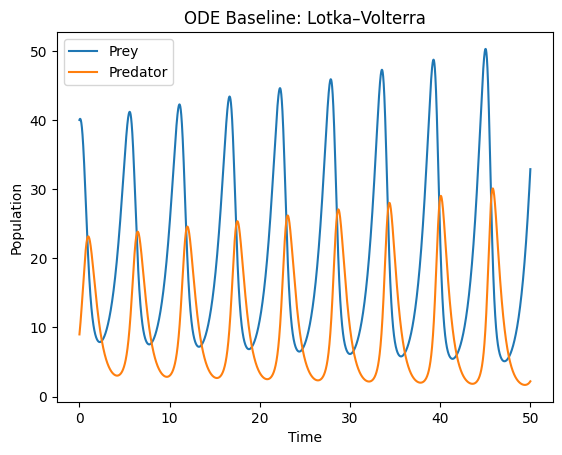

In [4]:
plt.figure()
plt.plot(T, X, label='Prey')
plt.plot(T, Y, label='Predator')
plt.title('ODE Baseline: Lotka–Volterra')
plt.xlabel('Time'); plt.ylabel('Population')
plt.legend(); plt.show()

## Spatial Agent-Based Model (ABM)

### Model Simulation

In [ ]:
params_no_refugia = ABMParams(refugia_fraction=0.0, adaptive_window=9999)
params_with_innov = ABMParams(refugia_fraction=0.15, adaptive_window=5)

print("Running ABM: no refugia/adapt ...")
prey1, pred1 = replicate_abm(run_abm, params_no_refugia, n_seeds=12)
print("Running ABM: refugia + adaptive ...")
prey2, pred2 = replicate_abm(run_abm, params_with_innov, n_seeds=12)

prey1_m, prey1_lo, prey1_hi = mean_ci(prey1)
pred1_m, pred1_lo, pred1_hi = mean_ci(pred1)
prey2_m, prey2_lo, prey2_hi = mean_ci(prey2)
pred2_m, pred2_lo, pred2_hi = mean_ci(pred2)

print("Done.")

Running ABM: no refugia/adapt ...
Running ABM: refugia + adaptive ...


### Quantitative Results

In [ ]:
print("<No Refugia/Adaptation>")
print(f"Prey: Min: {prey1_m.min():.3f}, Max: {prey1_m.max():.3f}, Mean: {prey1_m.mean():.3f}, Final: {prey1_m[-1]:.3f}")
print(f"Predator: Min: {pred1_m.min():.3f}, Max: {pred1_m.max():.3f}, Mean: {pred1_m.mean():.3f}, Final: {pred1_m[-1]:.3f}")

print("\n<Refugia + Adaptation>")
print(f"Prey:  Min: {prey2_m.min():.3f}, Max: {prey2_m.max():.3f}, Mean: {prey2_m.mean():.3f}, Final: {prey2_m[-1]:.3f}")
print(f"Predator: Min: {pred2_m.min():.3f}, Max: {pred2_m.max():.3f}, Mean: {pred2_m.mean():.3f}, Final: {pred2_m[-1]:.3f}")

### Visualisation

In [ ]:
plot_with_ci(prey1_m, prey1_lo, prey1_hi, 'ABM without innovation: Prey')
plot_with_ci(pred1_m, pred1_lo, pred1_hi, 'ABM without innovation: Predator')
plot_with_ci(prey2_m, prey2_lo, prey2_hi, 'ABM with refugia + adaptive prey: Prey')
plot_with_ci(pred2_m, pred2_lo, pred2_hi, 'ABM with refugia + adaptive prey: Predator')

## Extinction Probability

In [ ]:
print("Extinction probability (no refugia/adapt):")
print("  Prey:", extinction_prob(prey1))
print("  Pred:", extinction_prob(pred1))
print("Extinction probability (with refugia+adapt):")
print("  Prey:", extinction_prob(prey2))
print("  Pred:", extinction_prob(pred2))

Possible modifications:
- Adjust prey population (denser)
- Low energy cost to stress predators
- Natural prey death (natural disasters, accidents)
- Less/more protective refugia
- Longer simulation

## ODE vs ABM (Representative Run)

Slight difference were made to the numerical parameters of the ODE model, hence showing a subtle quantitative difference from the previous run. We doubled the step size `(dt = 0.02)` and ended the simulation earlier for less time to oscillate `(t_end=40)`.

In [ ]:
T, X, Y = lotka_volterra(x0=40, y0=9, params=ODEParams(t_end=40, dt=0.02)) 
P, Q = run_abm(ABMParams(steps=200, refugia_fraction=0.0, adaptive_window=9999), seed=7)

In [ ]:
# ODE results
print("<ODE Predator–Prey Dynamics>")
print(f"Prey: Min: [{X.min():.3f}, Max: {X.max():.3f}, Mean: {X.mean():.3f}, Final: {X[-1]:.3f}]")
print(f"Predator: Min: [{Y.min():.3f}, Max: {Y.max():.3f}, Mean: {Y.mean():.3f}, Final: {Y[-1]:.3f}]")

# ABM results
print("<ABM Predator–Prey Dynamics>")
print(f"Prey: Min: [{P.min():.3f}, Max: {P.max():.3f}, Mean: {P.mean():.3f}, Final: {P[-1]:.3f}]")
print(f"Predator: Min: [{Q.min():.3f}, Max: {Q.max():.3f}, Mean: {Q.mean():.3f}, Final: {Q[-1]:.3f}]")

### Visualisation

In [ ]:
plt.figure()
plt.plot(T, X, label='ODE Prey')
plt.plot(T, Y, label='ODE Pred')
plt.xlabel('Time'); plt.ylabel('Population')
plt.title('ODE baseline (representative)')
plt.legend(); plt.show()

plt.figure()
plt.plot(P, label='ABM Prey (seed 7)')
plt.plot(Q, label='ABM Pred (seed 7)')
plt.xlabel('Time step'); plt.ylabel('Population')
plt.title('ABM baseline (representative)')
plt.legend(); plt.show()

## Reproducibility and Parameters
- All stochastic simulations use fixed seeds; increase `n_seeds` for more robust statistics.
- Core parameters are centralized in the `ABMParams` dataclass.
- Re-running this notebook will regenerate all results and figures.